In [5]:
# this is to test the function for preprocessing stitched image for two artifact
# 1. The black corner patch
# 2. the red scale bar

In [6]:
import os 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from stitched_image_preprocessing import remove_red_scalebar,remove_corner_blackbox


In [7]:
image_folder = '/mnt/d/lding/DSI/promega/data/processed/ba296_1_Dy30'

/home/ldin/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/mnt/d/lding/DSI/promega/gitcode_20260211/2025-promega-mini-test/analysis/images/preprocessing/stitched_image_preprocessing.py:24: RuntimeWarning: invalid value encountered in cast
  x_filled[mask_missing] = f(t[mask_missing])


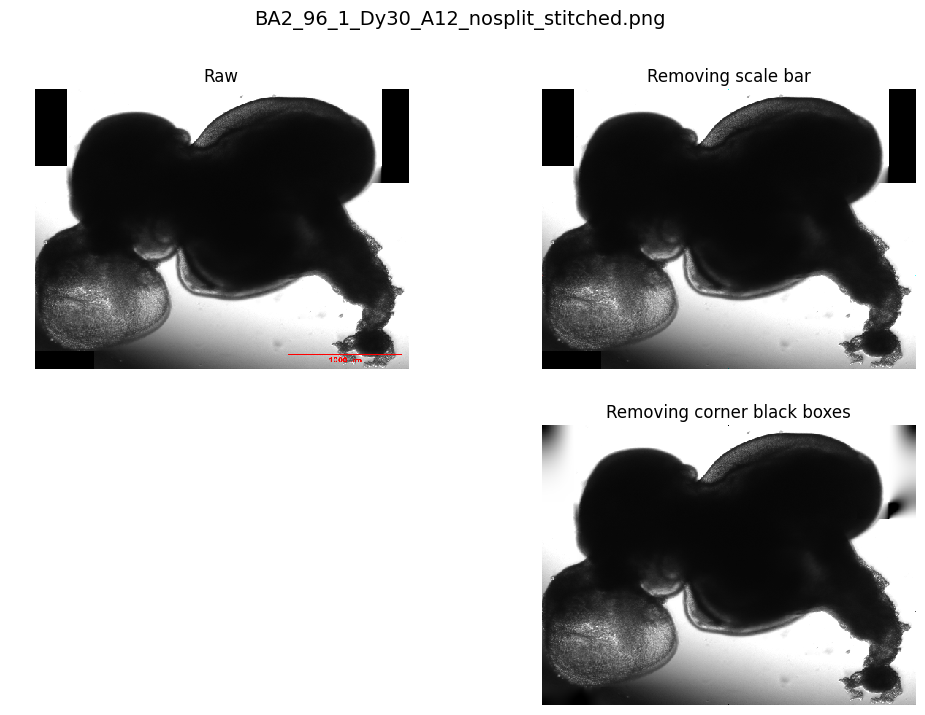

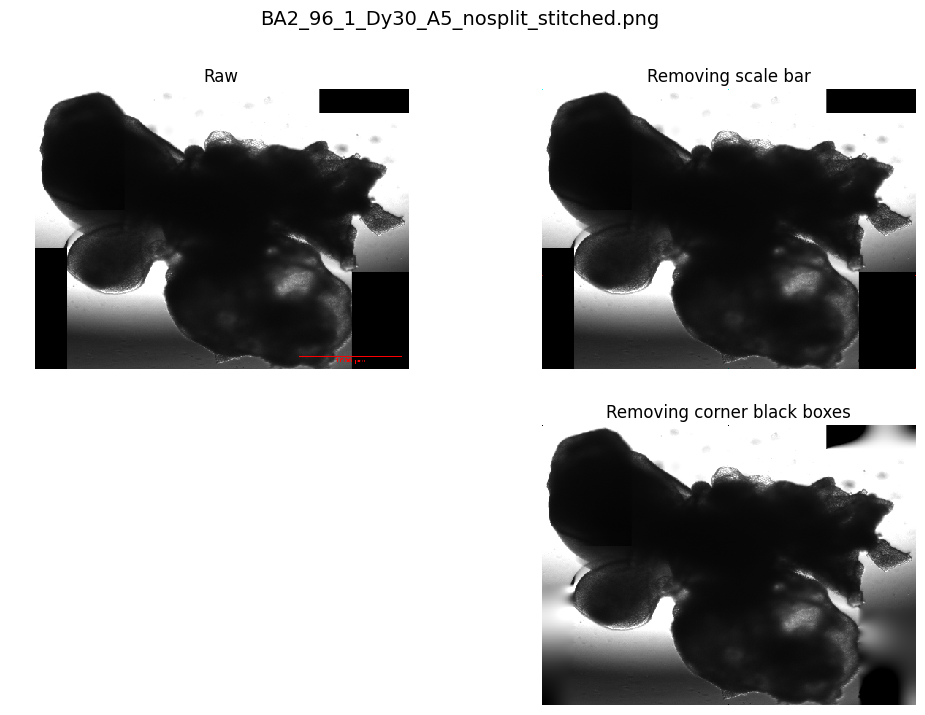

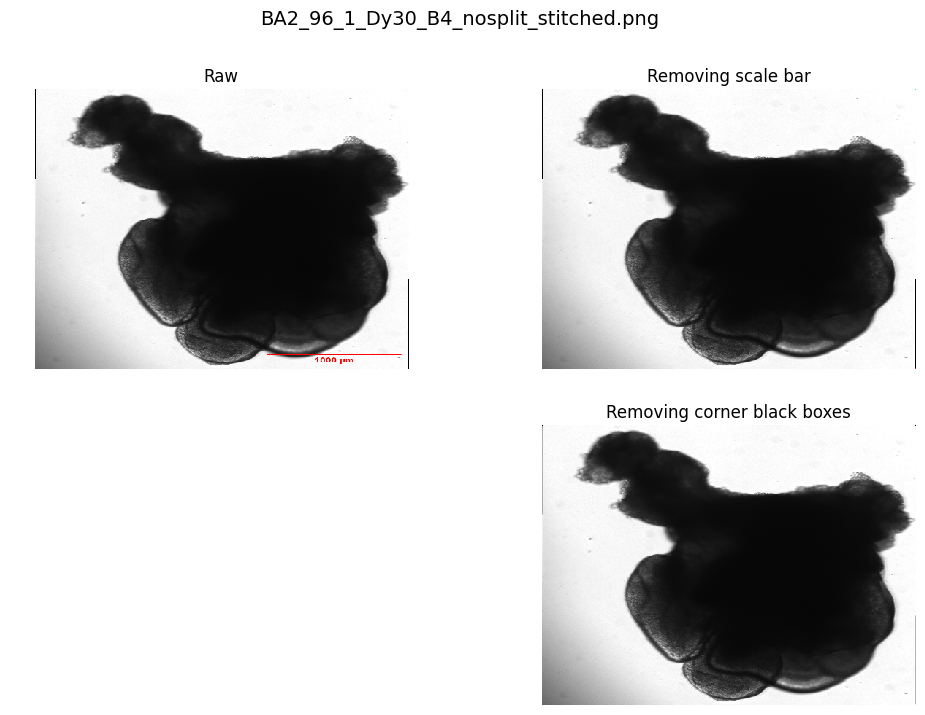

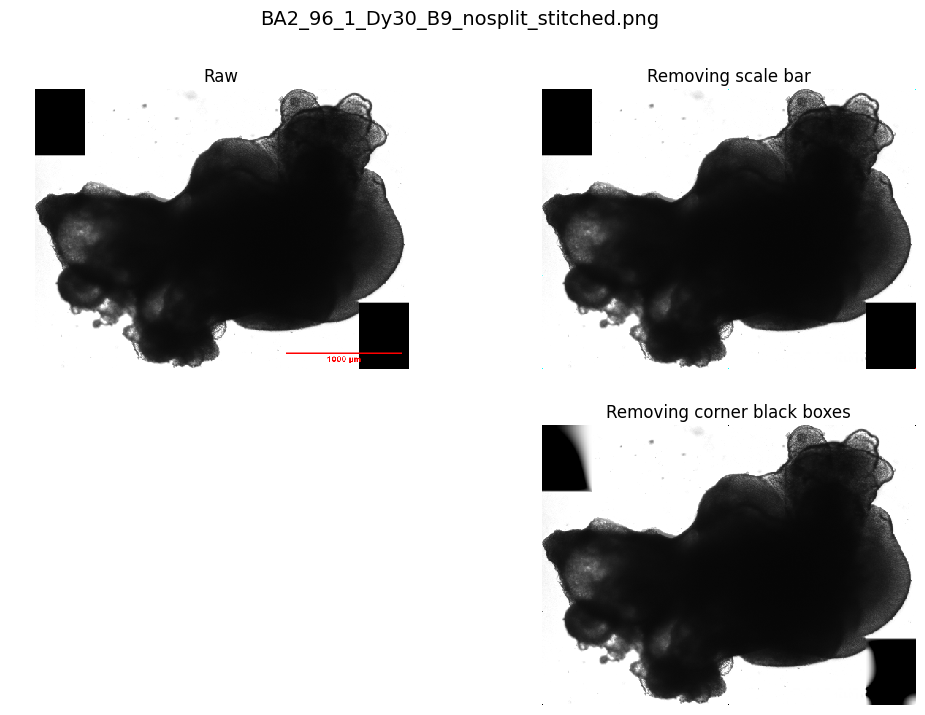

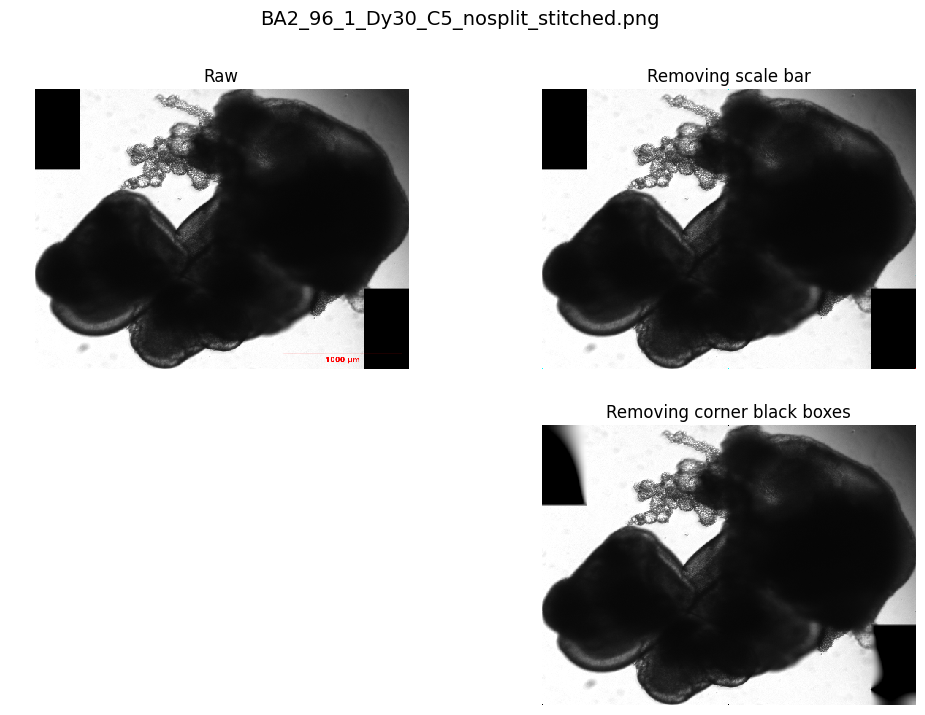

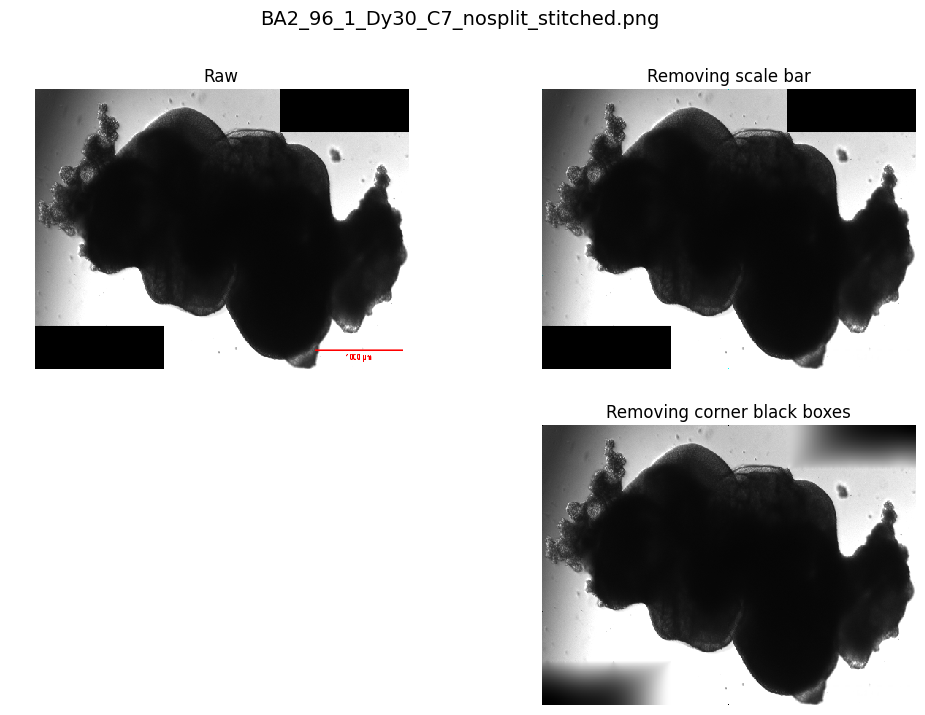

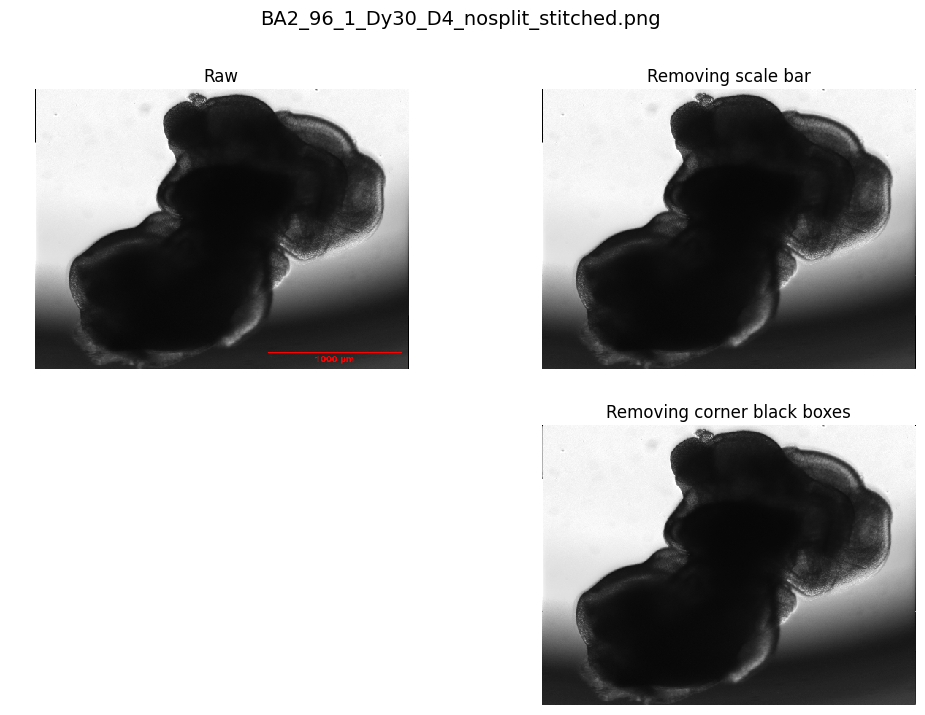

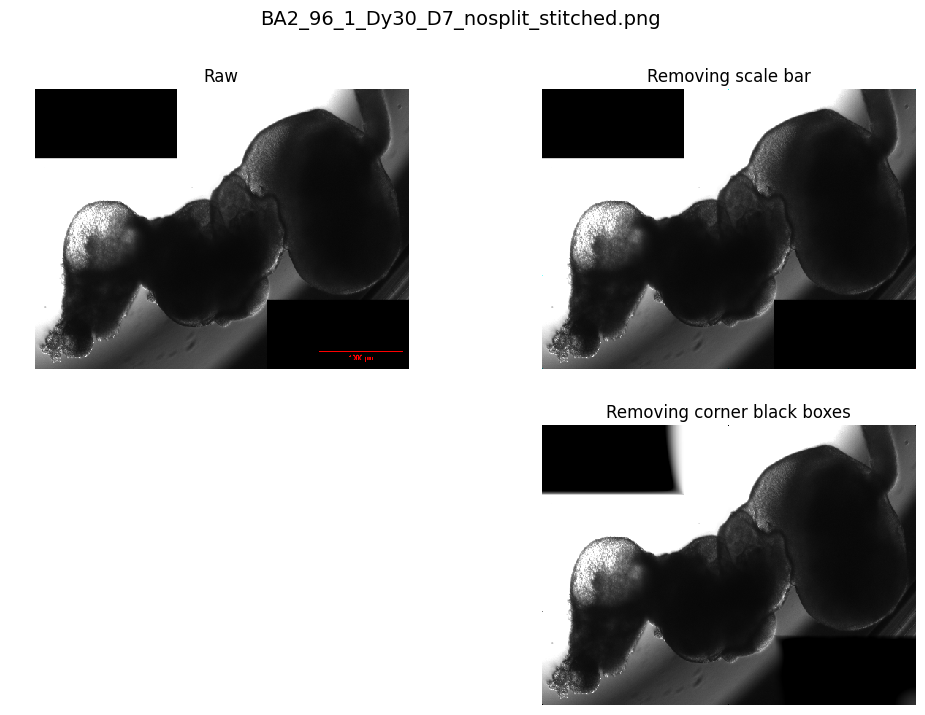

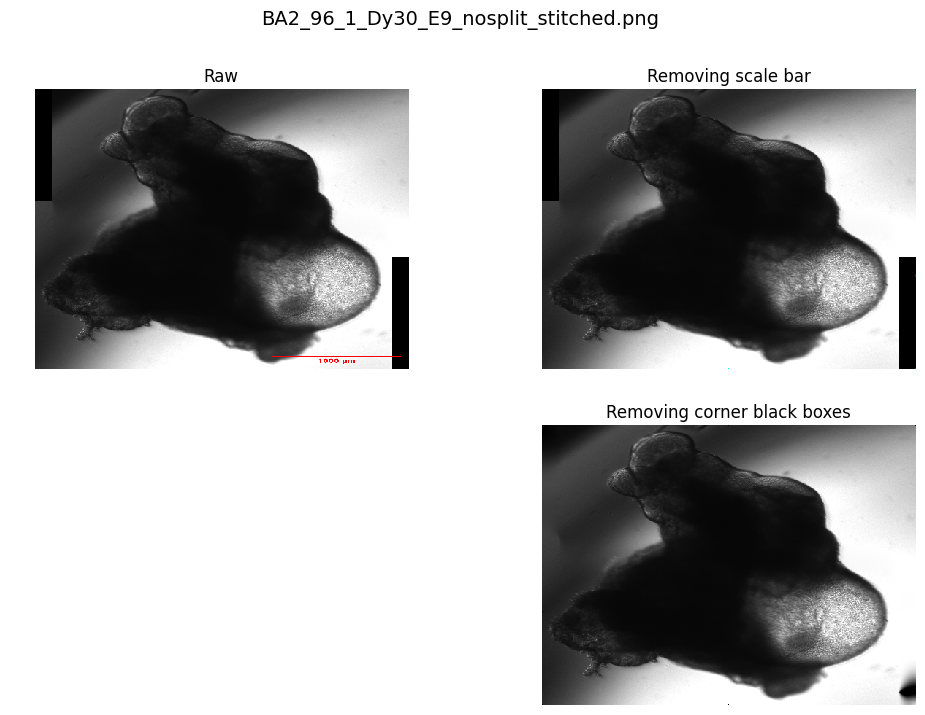

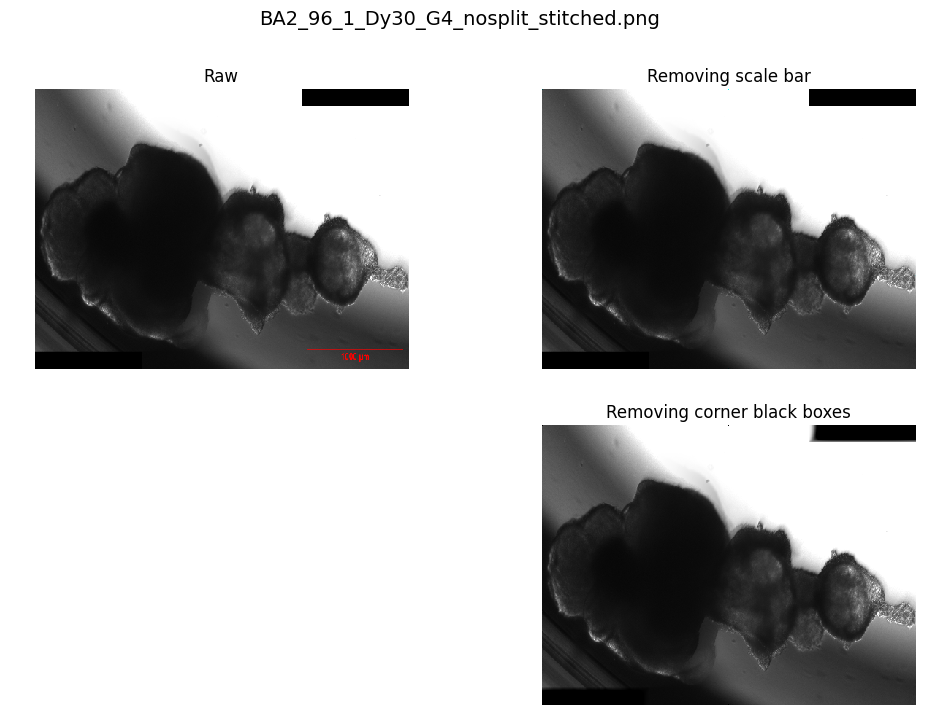

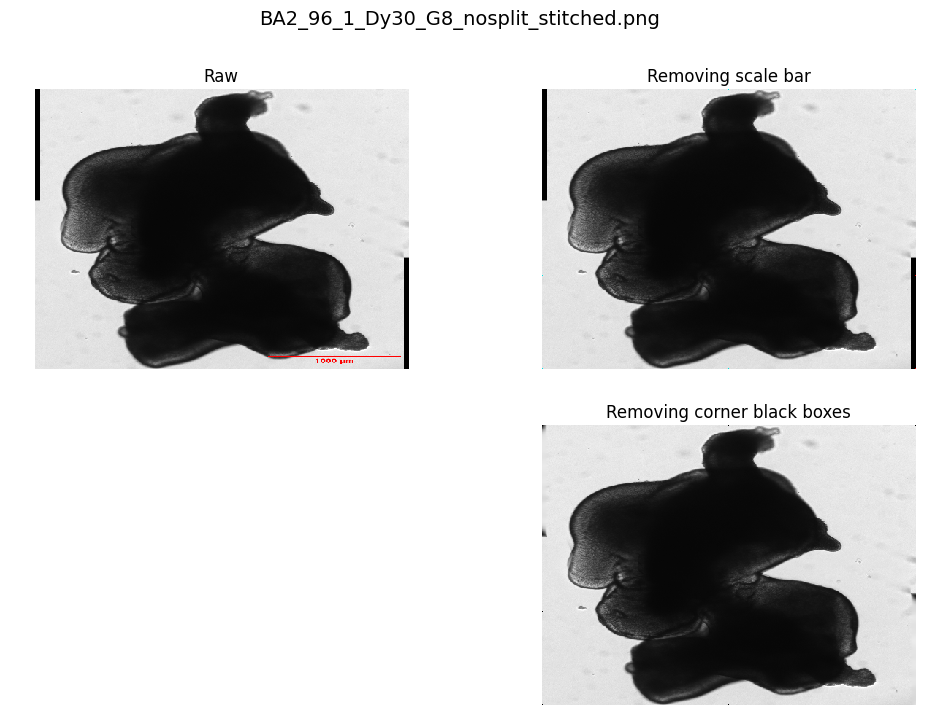

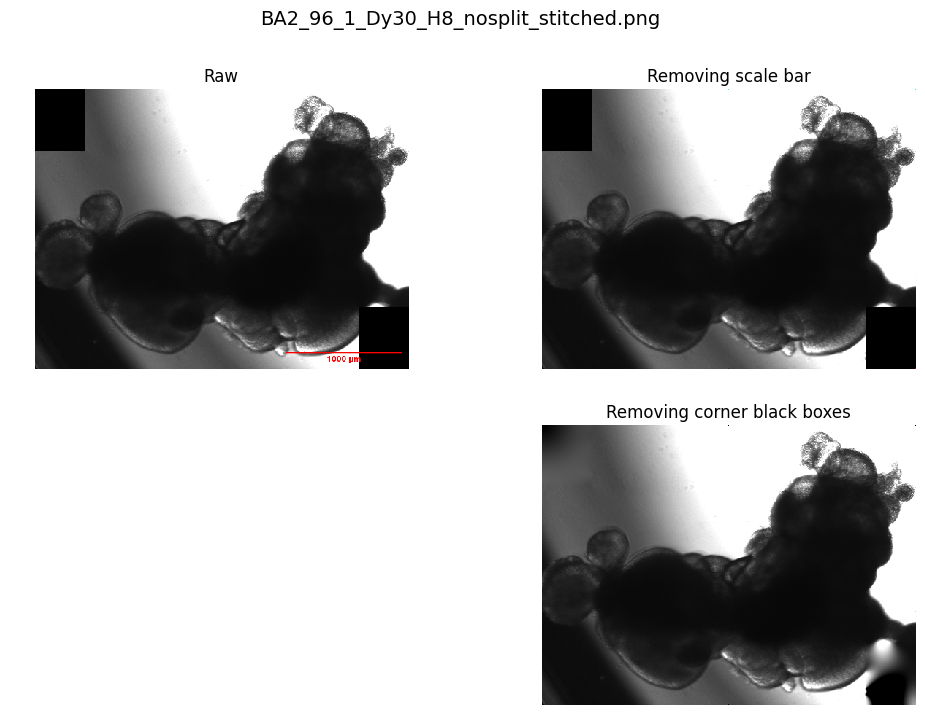

In [ ]:
# for each file that ends with _stitched.png
png_files = [f for f in os.listdir(image_folder) if f.lower().endswith("_stitched.png")]

for filename in png_files:
    # load image and convert to np array
    img = Image.open(os.path.join(image_folder, filename))   # lazy load
    img.load() 
    arr = np.array(img)

    # two steps, remove red scale bar, then remove black corner boxes
    img_remove_red = remove_red_scalebar(arr) 
    img_remove_black = remove_corner_blackbox(img_remove_red)
    # here we can save the img_remove_black as the updated image

    # or show here to check
    fig, ax = plt.subplots(2,2, figsize=(12,8))
    ax[0,0].imshow(img, interpolation='None')
    ax[0,0].axis('off')
    ax[0,0].set_title("Raw")
    fig.suptitle(filename, fontsize=14)
    ax[0,1].imshow(img_remove_red, interpolation='None')
    ax[0,1].set_title("Removing scale bar")
    ax[0,1].axis('off')
    ax[1,0].axis('off')
    ax[1,1].axis('off')
    ax[1,1].imshow(img_remove_black, interpolation='None')
    ax[1,1].set_title("Removing corner black boxes")    

